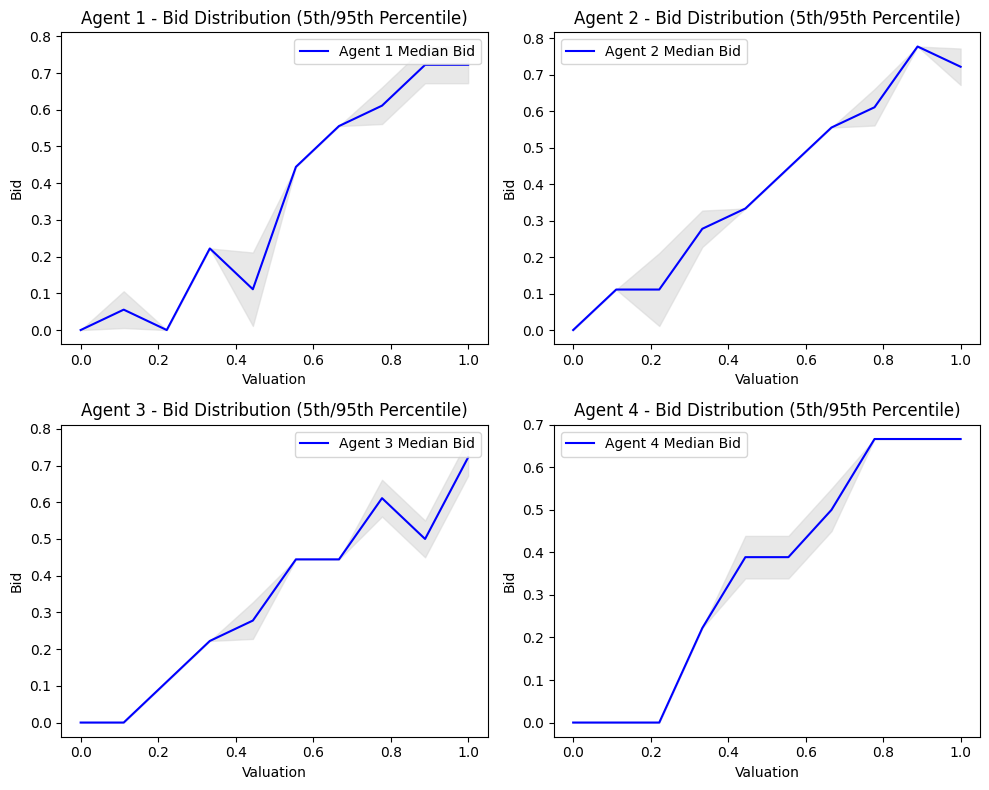

In [7]:
import numpy as np
import matplotlib.pyplot as plt

class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1, granularity=10, epsilon=0.1, alpha=0.1):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))  # Q-values for state-action pairs
        self.action_counts = np.zeros((granularity, len(self.actions)))  # Counts for state-action pairs
        self.reward_history = []
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def get_state(self, valuation):
        # Discretize the valuation into a state (bin)
        bins = np.linspace(0, 1, self.granularity + 1)
        return np.digitize(valuation, bins) - 1  # Bin index as the state
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            # Exploration: choose a random action
            return np.random.choice(self.actions)
        else:
            # Exploitation: choose the action with the highest Q-value for the current state
            return self.actions[np.argmax(self.q_values[self.state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[self.state, action_index] += 1
        # Update Q-values using the Q-learning update rule for the current state-action pair
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.reward_history.append(reward)
        self.update_q_values(action, reward)

class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None, winner_rule=None, epsilon_reward=0.001):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.winner_rule = winner_rule
        self.epsilon_reward = epsilon_reward
        self.profit_history = []

    def run_auction(self):
        for agent in self.agents:
            agent.refresh_valuation()

        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.winner_rule(bids)
        
        # The winner gets a reward equal to their surplus (valuation - payment) + epsilon reward for winning
        for idx, agent in enumerate(self.agents):
            reward = agent.valuation - payment + self.epsilon_reward if idx == winner_index else 0
            agent.feedback(reward, bids[idx])

        self.profit_history.append(payment)
        return {"winner": winner_index, "payment": payment, "bids": bids}

def run_single_simulation(agents, game, num_rounds=10000):
    for _ in range(num_rounds):
        game.run_auction()
    return [agent.q_values for agent in agents]

# Monte Carlo Simulation that captures the 5th, median, and 95th bid for each valuation
def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]

    for sim in range(num_simulations):
        run_single_simulation(agents, auction, num_rounds=num_rounds)
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    
    return percentiles

# Plot Bid vs. Valuation for each agent with Monte Carlo results in 2x2 grid
def plot_monte_carlo_results(agents, percentiles):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    valuations = np.linspace(0, 1, agents[0].granularity)

    for i, agent in enumerate(agents):
        ax = axes[i]
        ax.fill_between(valuations, percentiles[i]["5th"], percentiles[i]["95th"], color='lightgray', alpha=0.5)
        ax.plot(valuations, percentiles[i]["median"], label=f'Agent {i+1} Median Bid', color='blue')
        ax.set_xlabel('Valuation')
        ax.set_ylabel('Bid')
        ax.set_title(f'Agent {i+1} - Bid Distribution (5th/95th Percentile)')
        ax.legend()

    plt.tight_layout()
    plt.show()

# Section 2 - Running Monte Carlo simulation and plotting
if __name__ == "__main__":
    np.random.seed(0)
    
    # Create agents for the auction
    agents_fp = [QLearningAgent() for _ in range(4)]

    def first_price_rule(bids):
        max_bid = np.max(bids)
        winner_candidates = np.where(bids == max_bid)[0]
        if len(winner_candidates) > 1:
            # If there's a tie, pick a random winner among the candidates
            winner_index = np.random.choice(winner_candidates)
        else:
            winner_index = winner_candidates[0]
        payment = bids[winner_index]
        return winner_index, payment
    
    # First Price Auction with epsilon reward for winning
    first_price_auction = SingleSidedAuction(
        agents_fp, 
        price_floor=0, 
        price_ceiling=1, 
        payment_rule=first_price_rule, 
        winner_rule=first_price_rule,
        epsilon_reward=0.01  # Add epsilon reward for winning
    )

    # Run Monte Carlo simulations and get percentiles
    percentiles = run_monte_carlo_simulation(agents_fp, first_price_auction, num_simulations=2, num_rounds=10000)

    # Plot the Monte Carlo results in a 2x2 grid
    plot_monte_carlo_results(agents_fp, percentiles)